# **Student Stress Analysis using Machine Learning**

This project analyzes student stress patterns using machine learning techniques.  
The goal is to:
- Understand key factors contributing to stress
- Identify different types of students using clustering
- Build a predictive model for stress levels

Techniques used:
- PCA (Dimensionality Reduction)
- K-Means Clustering (Pattern Discovery)
- LASSO Regression (Prediction + Feature Selection)
- Random Forest Classification (Prediction + Feature selection)


## **Data Loading and Setup**

In this section, the proper libraries were imported and the dataset was taken from Kaggle.

The data taken from *[Sultanul Ovi's Student Stress Monitoring Datasets](https://www.kaggle.com/datasets/mdsultanulislamovi/student-stress-monitoring-datasets?select=Stress_Dataset.csv)*  was comprised of two main datasets:
- StressLevelDataset: structured numerical features (main dataset)
- Stress_Dataset: survey-based questions (used for reference)

In this instance,the structured dataset is used for the models.

In [110]:
# Data Handling + Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Machine Learning Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, silhouette_score, classification_report, confusion_matrix
# UI - Streamlit
# import streamlit as st
# Datasets Provided by Kaggle
import kagglehub

In [111]:
path = kagglehub.dataset_download("mdsultanulislamovi/student-stress-monitoring-datasets")
print(os.listdir(path))
stress_level_df = pd.read_csv(os.path.join(path, "StressLevelDataset.csv"))

print("Loaded shapes:")
print("StressLevel:", stress_level_df.shape)
print("Loaded columns:")
print(stress_level_df.columns)

Using Colab cache for faster access to the 'student-stress-monitoring-datasets' dataset.
['StressLevelDataset.csv', 'Stress_Dataset.csv']
Loaded shapes:
StressLevel: (1100, 21)
Loaded columns:
Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')


## **Data Cleaning**

Before applying machine learning, the dataset is cleaned through:
- Standardizing column names
- Removing duplicate rows
- Removing duplicate columns

This ensures consistency and avoids errors during modeling.

In [112]:
# helper function to clean the stress level dataset
def clean_cols(df):
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
    return df

stress_level_df = clean_cols(stress_level_df)
stress_level_clean = stress_level_df.drop_duplicates().copy()

print("\nAfter duplicate removal:")
print("StressLevel:", stress_level_clean.shape)
print("\nColumns (StressLevel):", list(stress_level_clean.columns))
stress_level_clean.to_csv("stress.csv", index = False)


After duplicate removal:
StressLevel: (1100, 21)

Columns (StressLevel): ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']


## **Exploratory Data Analysis (EDA)**

A quick EDA is performed on the dataset to understand:
- Distribution of stress levels via countplot
- Relationships between features via heat map

This helps identify patterns and validates that the data is suitable for modeling.

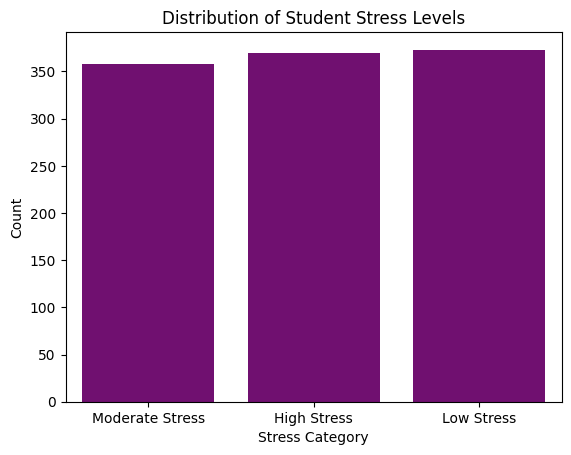

In [124]:
#quick EDA of stress_level_clean dataset
# Distribution of stress
stress_map = { 0: "Low Stress", 1: "Moderate Stress", 2: "High Stress"}
stress_level_clean["stress_label"] = (stress_level_clean["stress_level"].map(stress_map))
sns.countplot(x="stress_label",data=stress_level_clean, color = "purple")
plt.title("Distribution of Student Stress Levels")
plt.xlabel("Stress Category")
plt.ylabel("Count")
plt.savefig("stress_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

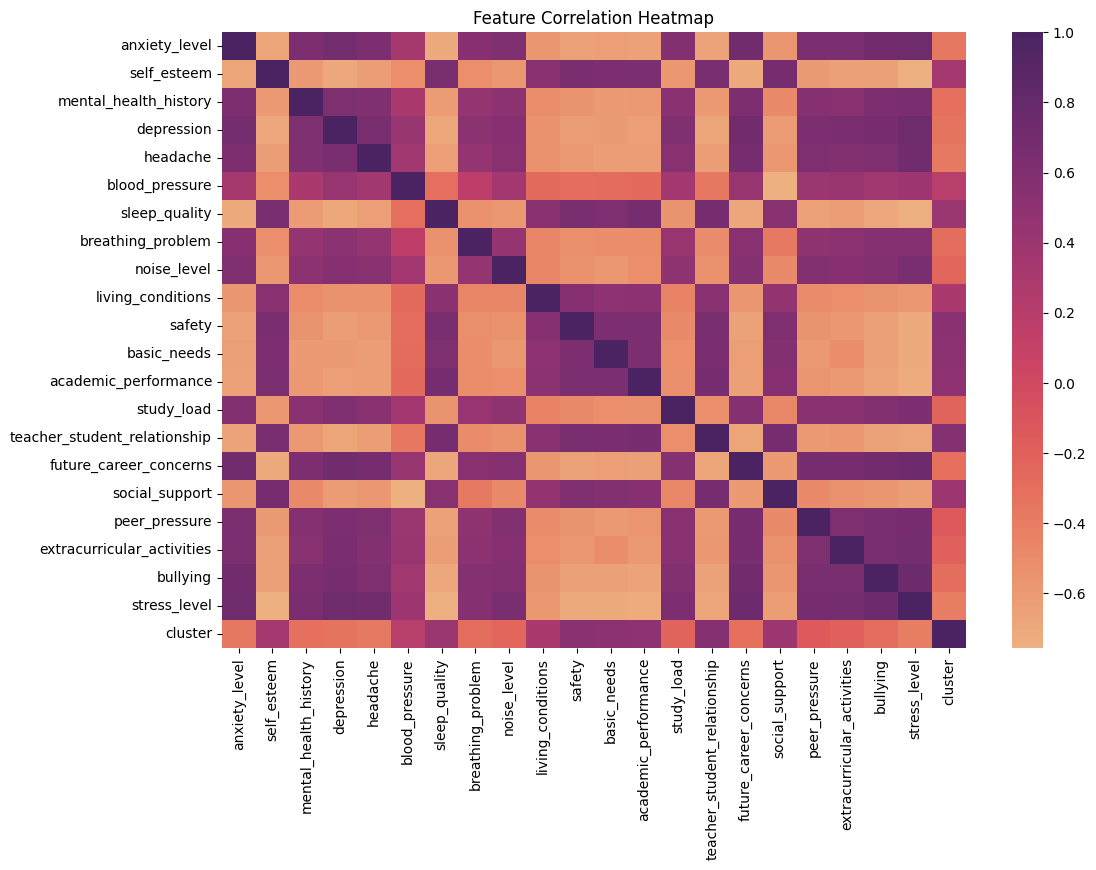

In [125]:
# Correlation heatmap
numeric_df = stress_level_clean.select_dtypes(include=['number'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="flare")
plt.title("Feature Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


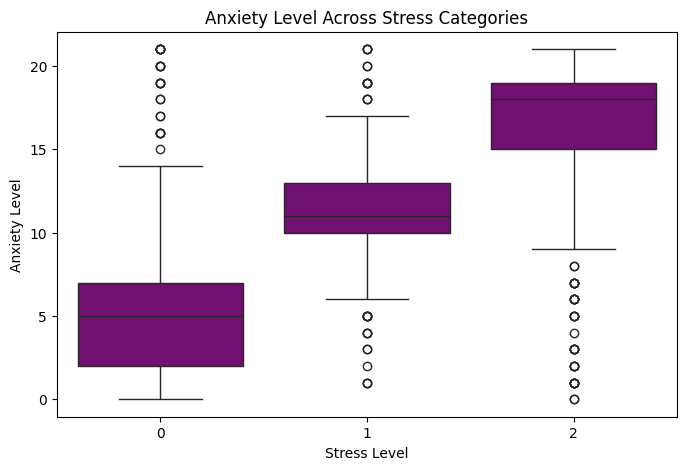

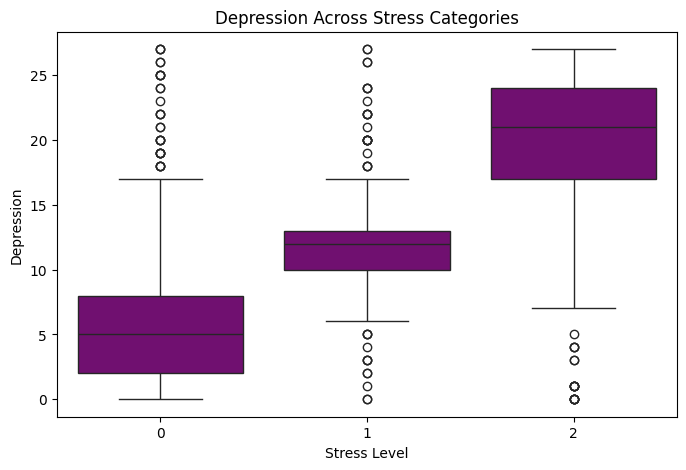

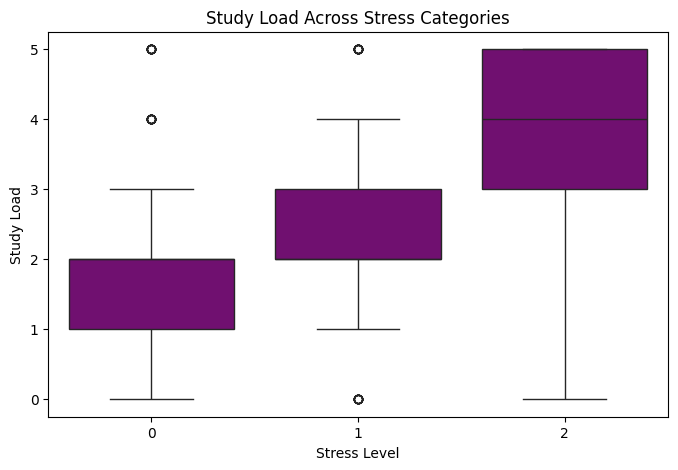

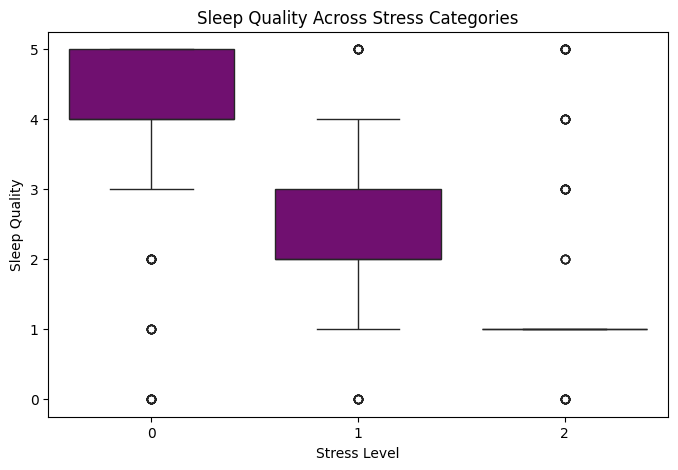

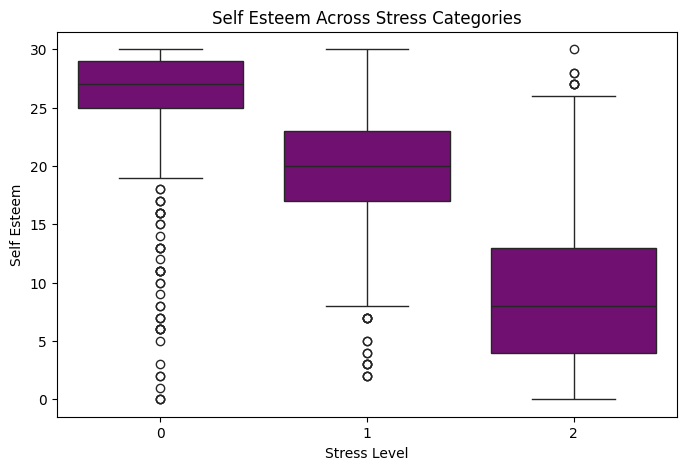

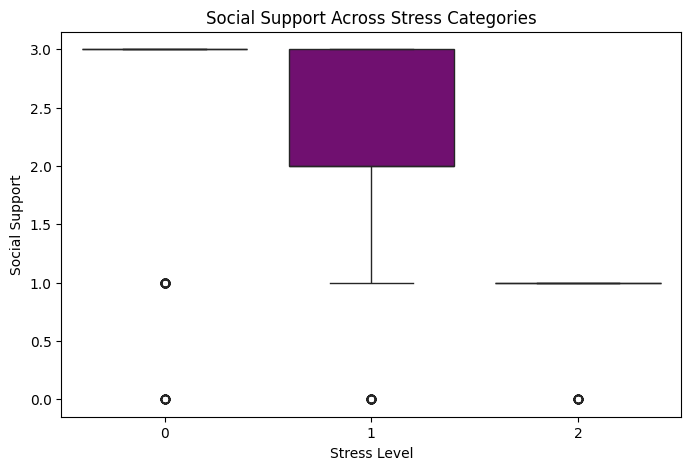

In [126]:
features = ["anxiety_level", "depression","study_load","sleep_quality","self_esteem","social_support"]

for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="stress_level",y=feature, data=stress_level_clean, color ="purple")
    plt.title( f"{feature.replace('_', ' ').title()} Across Stress Categories")
    plt.xlabel("Stress Level")
    plt.ylabel(feature.replace('_', ' ').title())
    plt.savefig("features_boxplot.png", dpi=300, bbox_inches='tight')
    plt.show()

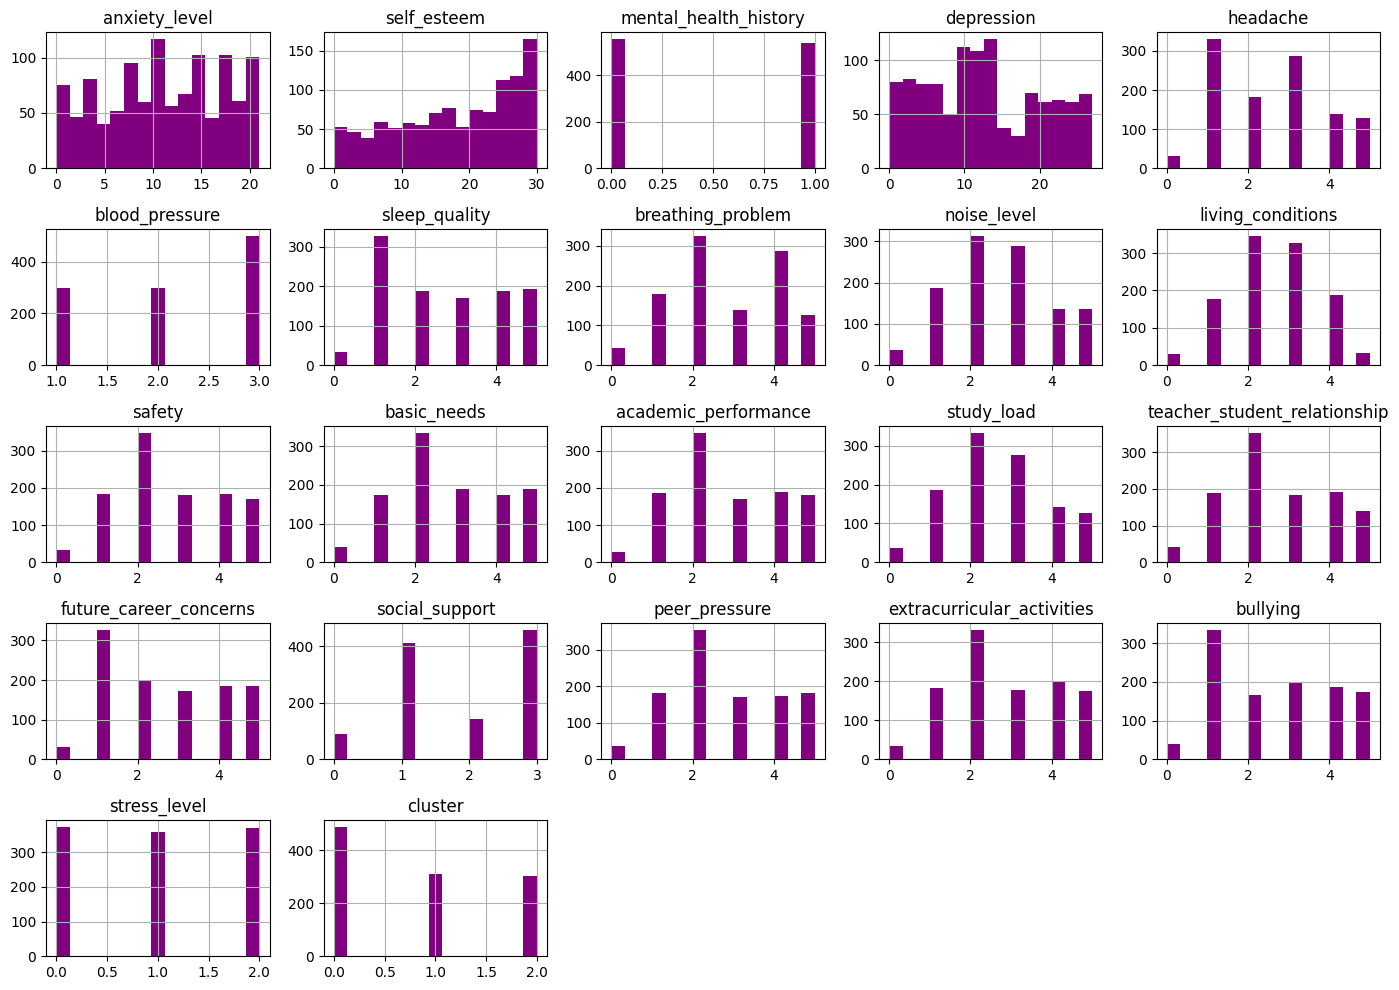

In [127]:
stress_level_clean.hist(figsize=(14,10),bins=15, color="purple")
plt.tight_layout()
plt.savefig("data_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

## **Feature Selection and Standardization**

The stress level column is dropped from the main dataframe to create:
- X: input features (habits, behaviors)
- y: target variable (stress level)

Then the StandardScaler is applied to X in order to normalize all features.

This step is critical because PCA and clustering depend on feature scale.

In [128]:
#feature selection and standardization
X = numeric_df.drop("stress_level", axis=1)
y = numeric_df["stress_level"]
scaler = StandardScaler()
scaled = scaler.fit_transform(X)

## **Principal Component Analysis (PCA)**

PCA reduces the number of features while preserving most of the information.

The parameter n_components is set to 0.9 to retain 90% of the variance.

This helps to:
- Removes noise
- Improves clustering performance
- Simplifies the dataset

###  **PCA Explained Variance**

This plot shows how much information is retained as we increase components.


Original shape: (1100, 21)
Reduced shape: (1100, 13)


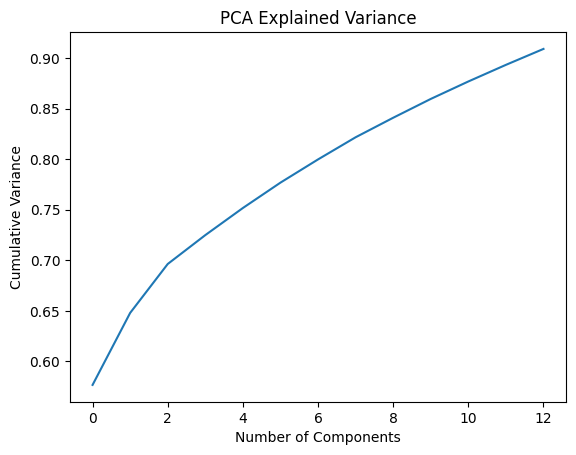

In [129]:
# PCA
pca = PCA (n_components=0.9) # helps to maintain high variance in the data, reduce noise and features used
X_pca = pca.fit_transform(scaled)

print("Original shape:", scaled.shape)
print("Reduced shape:", X_pca.shape)

# Graph helps to show how much variance (information) is captured as the number of principal components increases.
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.savefig("pca_variance.png", dpi=300, bbox_inches='tight')
plt.show()

## **Initial Clustering (K=3)**

As a baseline, the KMeans model is applied using 3 clusters. This helps to identify general groupings of students based on their behavior patterns.

         anxiety_level  self_esteem  ...  bullying  stress_level
cluster                              ...                        
0            10.940574    18.131148  ...  2.456967      0.993852
1            17.916399     7.871383  ...  4.427653      1.964630
2             4.182724    27.438538  ...  1.006645      0.000000

[3 rows x 21 columns]


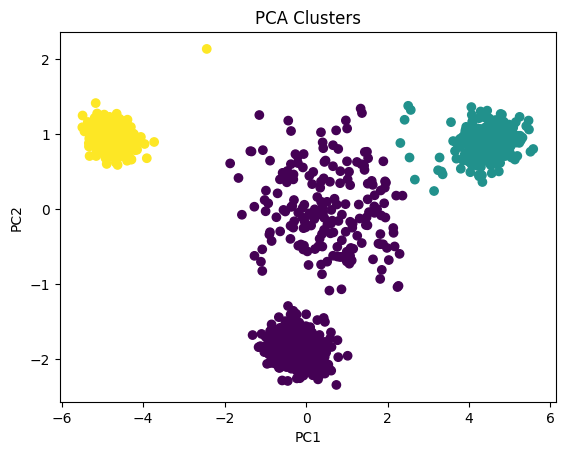

In [130]:
# clustering and student profiles
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
numeric_df["cluster"] = clusters
print(numeric_df.groupby("cluster").mean())

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clusters")
plt.savefig("clusters_3.png", dpi=300, bbox_inches='tight')
plt.show()


## **Interpreting Principal Components**

Principal components are linear combinations of the original features. However, on their own, they do not have an intuitive or direct meaning.

To interpret them, **PCA loadings** are used. Loadings represent the coefficients of each original variable in a principal component, showing how strongly each feature contributes to that component.

- High positive values indicate a strong positive contribution
- Negative values indicate an inverse relationship

By examining these loadings, the data can be assigned real-world meaning to each component. For example:
- PC1 may represent overall stress intensity
- PC2 may represent different types of stress (e.g., emotional vs. physical)

Without analyzing the loadings, PCA results would remain abstract and difficult to connect to meaningful behavioral patterns.

In [131]:
loadings = pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=X.columns)

PC1_factors = pd.DataFrame(loadings["PC1"].sort_values(ascending=False))
PC2_factors = pd.DataFrame(loadings["PC2"].sort_values(ascending=False))

In [132]:
PC1_factors

,PC1
future_career_concerns,0.244559
anxiety_level,0.242039
depression,0.240203
bullying,0.239801
headache,0.227651
extracurricular_activities,0.222216
peer_pressure,0.222090
mental_health_history,0.216830
noise_level,0.206179
study_load,0.201539


In [133]:
PC2_factors

,PC2
blood_pressure,0.615783
cluster,0.615322
academic_performance,0.171206
safety,0.166126
basic_needs,0.158518
peer_pressure,0.152858
extracurricular_activities,0.150428
teacher_student_relationship,0.139814
study_load,0.098467
sleep_quality,0.083320


## **Choosing an Accurate Number of Clusters**
While looking at the scatterplot before, there seems to be two different groups in the purple section. To debunk whether 3 or 4 clusters should be used for more accurate data, silhouette scores were used to evaluate clustering quality for different instances of K.

This helps to determine the optimal number of clusters based on:
- Separation between groups
- Cohesion within groups

Overall, the graph highlighted a severe bend when K=4, which shows that 4 clusters are useful when analyzing this data. If K=5, it would be overfitting.

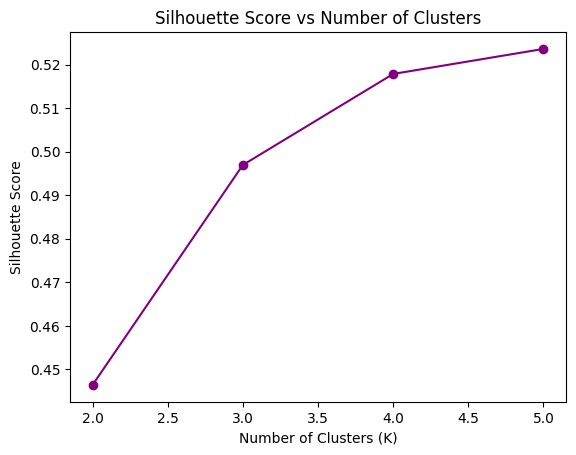

In [134]:
k_values = list(range(2, 6))
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot
plt.figure()
plt.plot(k_values, scores, marker='o', color ="purple")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.savefig("silhouette_scores.png", dpi=300, bbox_inches='tight')
plt.show()


## **Final Clustering (K=4)**

Based on silhouette scores and PCA visualization, K=4 is used instead of K=3.

This captures:
- Low stress students
- Moderate stress students
- High emotional stress students
- High general stress students

### **Cluster Interpretation**

Clusters are labeled based on their feature averages and PCA position.

This step converts numerical clusters into meaningful categories of student behavior.

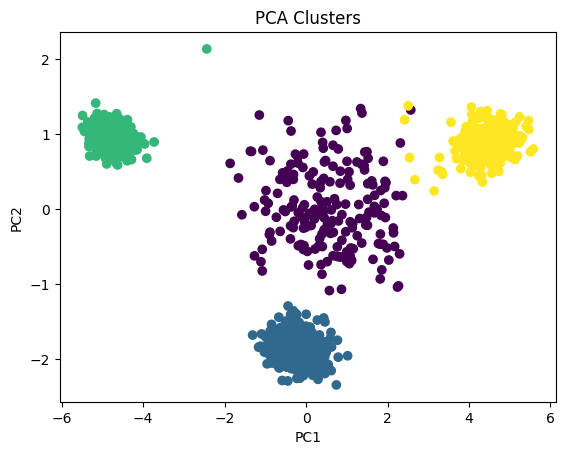

In [136]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)
numeric_df["cluster"] = clusters
cluster_df = pd.DataFrame(numeric_df.groupby("cluster").mean())

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clusters")
plt.savefig("clusters_4.png", dpi=300, bbox_inches='tight')
plt.show()

In [137]:
cluster_df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
cluster,,,,,,,,,,,,,,,,,,,,,
0,10.215789,15.084211,0.421053,13.042105,2.631579,3.000000,2.768421,2.352632,2.515789,2.573684,2.294737,2.452632,2.578947,2.457895,1.942105,2.589474,0.557895,2.221053,2.536842,2.305263,0.978947
1,11.410000,19.980000,0.513333,11.640000,2.483333,1.000000,2.456667,3.026667,2.523333,2.483333,2.476667,2.513333,2.473333,2.486667,2.483333,2.460000,2.526667,2.466667,2.483333,2.560000,1.000000
2,4.182724,27.438538,0.000000,4.172757,1.000000,2.003322,4.488372,1.514950,1.468439,3.531561,4.491694,4.514950,4.504983,1.485050,4.465116,1.003322,2.993355,1.524917,1.501661,1.006645,0.000000
3,17.951456,7.883495,0.996764,21.310680,3.925566,3.000000,1.009709,3.941748,4.003236,1.530744,1.553398,1.524272,1.495146,3.961165,1.472492,4.472492,0.987055,4.488673,4.417476,4.433657,1.974110


In [138]:
cluster_labels = {
    0: "Moderate Stress",        # green
    1: "High Emotional Stress",  # blue (bottom)
    2: "Low Stress",             # red (left)
    3: "High General Stress"     # orange (right) mainly about future career goals
}

stress_level_clean["cluster_label"] = stress_level_clean["cluster"].map(cluster_labels)
print(stress_level_clean.columns)
print(stress_level_clean["cluster_label"].isnull().sum())
print(stress_level_clean["cluster"].unique())


Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level',
       'stress_label', 'cluster', 'cluster_label'],
      dtype='object')
0
[1 3 0 2]


## **Visualizing Labeled Clusters**

The clusters in PCA space are then plotted and assigned labels. This helps visualize how different student groups are distributed within the data.

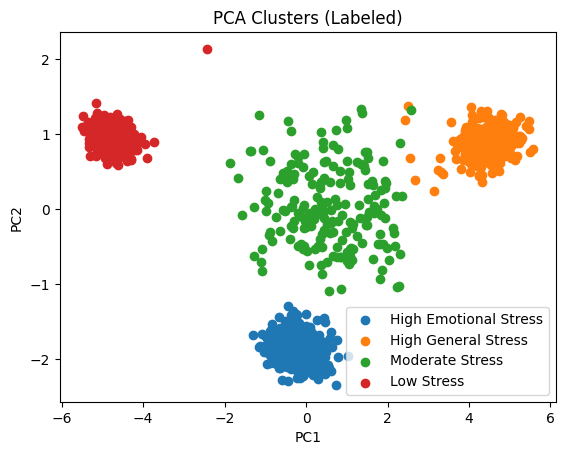

In [139]:
if "cluster_label" not in stress_level_clean.columns:
    print("cluster_label column missing!")
else:
    plt.figure()

    for label in stress_level_clean["cluster_label"].dropna().unique():
        subset = stress_level_clean[stress_level_clean["cluster_label"] == label]

        plt.scatter(X_pca[subset.index, 0],X_pca[subset.index, 1],label=label)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Clusters (Labeled)")
    plt.legend()
    plt.savefig("labeled_clusters.png", dpi=300, bbox_inches='tight')
    plt.show()
    # postive pc1 = anxiety, depression, workload perr pressure, negative pc1 = self esteem and social support
    # positive pc2 = physical/environmental stability, negative  = emotional and psycological stress

## **LASSO Regression (Prediction + Feature Selection)**

LASSO regression is then used to:
- Predict stress levels
- Identify the most important contributing factors

LASSO automatically removes less important features by setting coefficients to zero.

The model is evaluated via:
- R² score (explained variance)
- RMSE (prediction error)

These metrics indicate how well the model predicts stress levels.

In [140]:
# LASSO Regression

X_train, X_test, y_train, y_test = train_test_split(scaled, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


lasso_df = pd.DataFrame({"Feature": X.columns,"Coefficient": lasso.coef_})
lasso_df = lasso_df[lasso_df["Coefficient"] != 0]
lasso_df["Abs_Coefficient"] = lasso_df["Coefficient"].abs()
lasso_df["Effect"] = lasso_df["Coefficient"].apply(lambda x: "Increases Stress" if x > 0 else "Reduces Stress")
lasso_df = lasso_df.sort_values(by="Abs_Coefficient", ascending=False)
lasso_df = lasso_df.reset_index(drop = True)


R2 Score: 0.7709097801672017
RMSE: 0.39109536930323185


In [141]:
lasso_df

,Feature,Coefficient,Abs_Coefficient,Effect
0,bullying,0.105446,0.105446,Increases Stress
1,self_esteem,-0.103680,0.103680,Reduces Stress
2,basic_needs,-0.081085,0.081085,Reduces Stress
3,extracurricular_activities,0.077716,0.077716,Increases Stress
4,noise_level,0.070826,0.070826,Increases Stress
5,safety,-0.063878,0.063878,Reduces Stress
6,depression,0.052663,0.052663,Increases Stress
7,academic_performance,-0.050350,0.050350,Reduces Stress
8,sleep_quality,-0.045405,0.045405,Reduces Stress
9,study_load,0.036361,0.036361,Increases Stress


## **Random Forest Classification Analysis**



In [142]:
rf = RandomForestClassifier( n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8818181818181818


              precision    recall  f1-score   support

           0       0.84      0.88      0.86        76
           1       0.92      0.89      0.90        73
           2       0.90      0.87      0.89        71

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



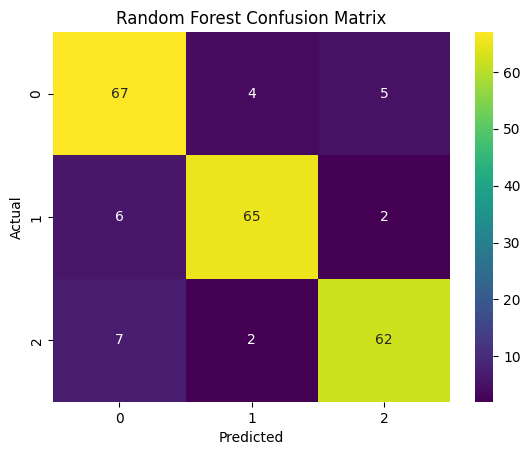

In [143]:
print(classification_report(y_test, rf_pred))
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d',cmap='viridis')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.savefig("rf_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

## **Feature Importance Analysis**
Based on the LASSO coefficients, it is shown that positive coefficients increases stress and negative coefficients reduces stress.

In [144]:
# lasso coefficents
coef_df = pd.Series(lasso.coef_, index=X.columns)
coef_df = coef_df.sort_values()

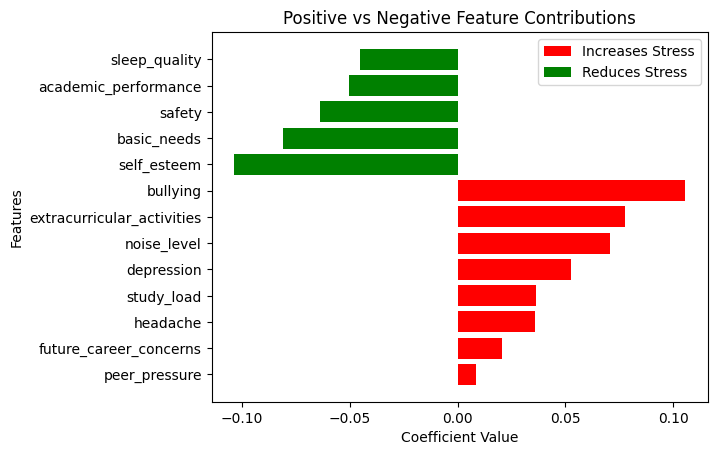

In [145]:
#color coded map
pos = coef_df[coef_df > 0]
neg = coef_df[coef_df < 0]

plt.figure()
plt.barh(pos.index, pos.values, color='red', label='Increases Stress')
plt.barh(neg.index, neg.values, color='green', label='Reduces Stress')
plt.legend()

plt.title("Positive vs Negative Feature Contributions")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.savefig("pos_neg_lasso_coef.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_28071/393209956.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


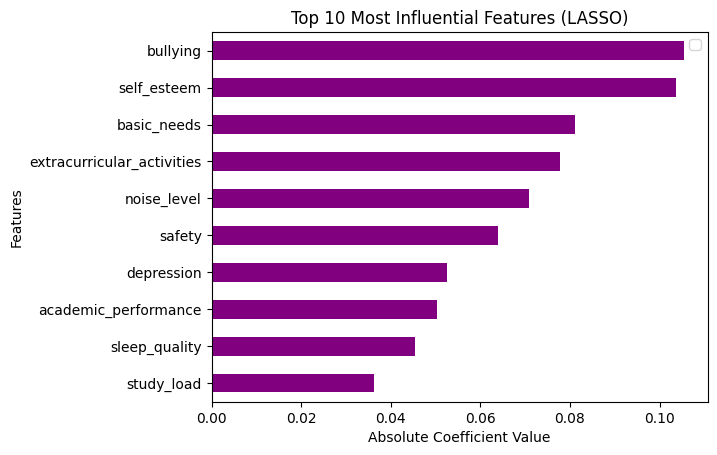

In [146]:
# top 10 features
top_features = coef_df.abs().sort_values(ascending=False).head(10)

plt.figure()
top_features.sort_values().plot(kind='barh', color='purple')
plt.legend()
plt.title("Top 10 Most Influential Features (LASSO)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Features")
plt.savefig("top_lasso_features.png", dpi=300, bbox_inches='tight')
plt.show()

In [147]:
# important factors based on Random Forest classifier
importance_df = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})
importance_df = importance_df.sort_values(by="Importance",ascending=False)
print(importance_df)

                         Feature  Importance
5                 blood_pressure    0.124473
18    extracurricular_activities    0.101000
19                      bullying    0.065096
20                       cluster    0.064120
16                social_support    0.063844
10                        safety    0.063581
0                  anxiety_level    0.058583
3                     depression    0.057997
14  teacher_student_relationship    0.050833
6                  sleep_quality    0.048373
4                       headache    0.045114
11                   basic_needs    0.044500
15        future_career_concerns    0.040216
17                 peer_pressure    0.036684
1                    self_esteem    0.036367
12          academic_performance    0.033155
8                    noise_level    0.018310
13                    study_load    0.016695
7              breathing_problem    0.014578
9              living_conditions    0.012619
2          mental_health_history    0.003862


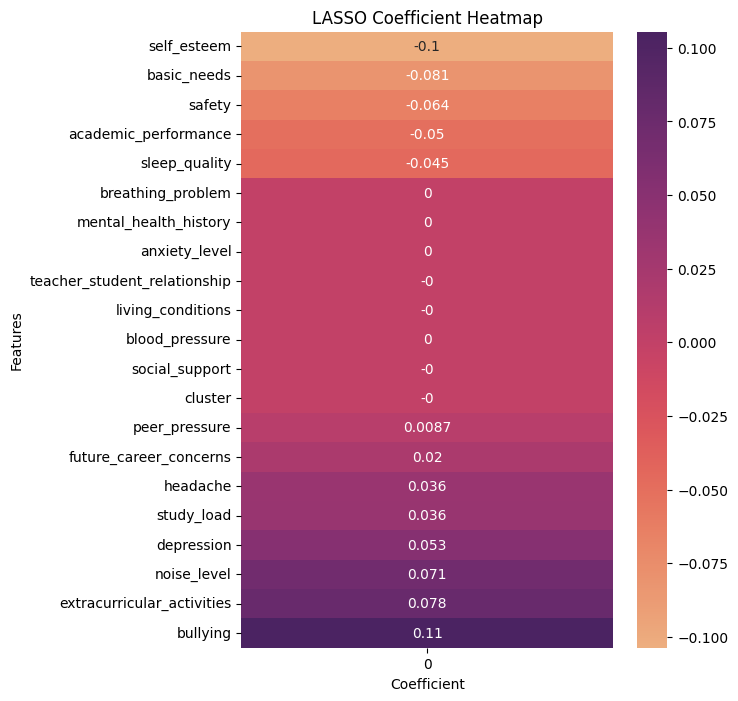

In [148]:
# heatmap
plt.figure(figsize=(6,8))
sns.heatmap(coef_df.to_frame(), annot=True, cmap="flare", center=0)
plt.title("LASSO Coefficient Heatmap")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.savefig("lasso_coef_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [149]:
#Saving Models
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(pca, open("pca.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))
pickle.dump(lasso, open("lasso.pkl", "wb"))
pickle.dump(rf, open("rf.pkl", "wb"))